In [ ]:
import matplotlib.pyplot as plt # libreira para gaficos
import seaborn as sns # libreria para distribuir los datos
import pandas as pd #libreria de manipulacion de datos
import re # módulo estándar de expresiones regulares


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

**PRIMERA PARTE: "Detector Inteligente de Spam con Python"**


---



1. Cargamos el dataset

In [ ]:
import csv

# 1. Cargamos el dataset
df = pd.read_csv(
    "/content/SpamCollectionSMS.txt",
    sep="\t",
    header=None,
    names=["etiqueta", "mensaje"], # nombres de columnas: etiqueta (ham/spam) y texto
    engine="python",
    quoting=csv.QUOTE_NONE,# no tratar comillas como especiales
    on_bad_lines="skip"  # si hay líneas rotas, las omite
)

# 2. Limpieza de las columnas para evitar caracteres raros
# Nos aseguramos de que la etiqueta sea string, en minúsculas y sin espacios extra.
# Lo mismo con todos los mensajes sean string
df["etiqueta"] = df["etiqueta"].astype(str).str.lower().str.strip()
df["mensaje"] = df["mensaje"].astype(str)


# 3. Vista preliminar de los datos
# Imprimimos las cinco primeras filas
print(df.head())

print("\nDistribución:")
print(df["etiqueta"].value_counts()) # Cuantos mensajes hay de cada tipo (ham/spam)
print("\nDistribución (%):")
print(df["etiqueta"].value_counts(normalize=True) * 100) # Porcentaje mensajes (ham/spam)

# 4. Vemos la calidad de los datos (Nulos y duplicados)
print("\nNulos:") # Número de valores nulos (NaN) por columna
print(df.isna().sum())

#En el caso de que haya filas se cuenta.
print("\nDuplicados (filas repetidas):", df.duplicated().sum())

  etiqueta                                            mensaje
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...

Distribución:
etiqueta
ham     4827
spam     747
Name: count, dtype: int64

Distribución (%):
etiqueta
ham     86.598493
spam    13.401507
Name: proportion, dtype: float64

Nulos:
etiqueta    0
mensaje     0
dtype: int64

Duplicados (filas repetidas): 403


2. EDA

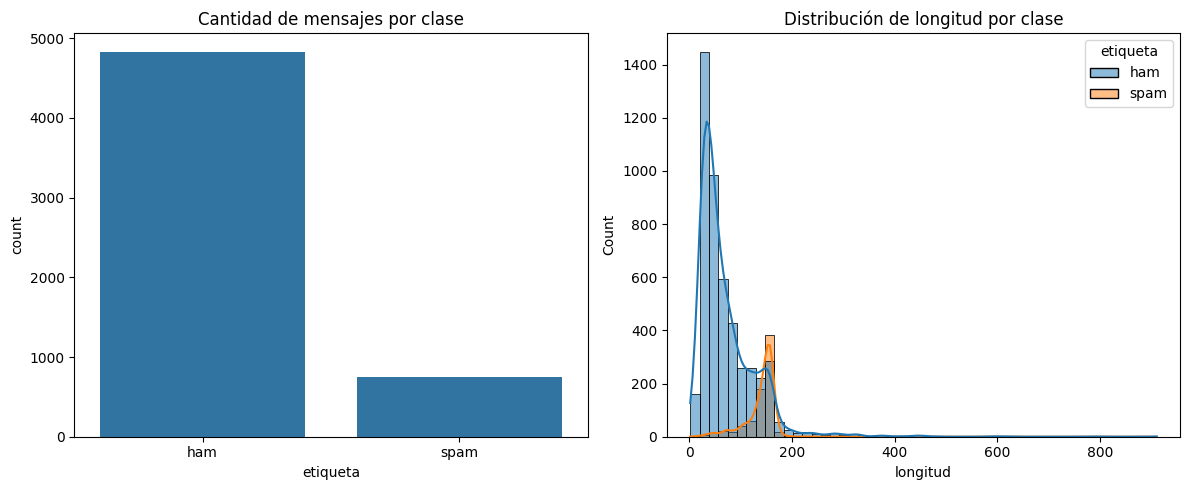

Palabras más frecuentes en HAM:
[('i', 2333), ('you', 1866), ('to', 1562), ('the', 1137), ('a', 1073), ('u', 1028), ('and', 858), ('in', 825), ('me', 777), ('my', 755), ('is', 738), ('it', 623), ('of', 526), ('for', 507), ('that', 501)]

Palabras más frecuentes en SPAM:
[('to', 691), ('a', 393), ('call', 370), ('you', 292), ('your', 264), ('free', 228), ('the', 206), ('for', 204), ('now', 203), ('or', 192), ('u', 181), ('p', 180), ('txt', 170), ('is', 158), ('on', 145)]


In [ ]:
df["longitud"] = df["mensaje"].str.len()

#gráficos  en una sola fila
fig, axes = plt.subplots(1, 2, figsize=(12, 5))# 1 fila, 2 columnas de gráficos

# Primer subplot: distribución de clases (cuántos ham y cuántos spam)
sns.countplot(x="etiqueta", data=df, ax=axes[0])
axes[0].set_title("Cantidad de mensajes por clase")

# Segundo subplot: distribución de la longitud de los mensajes por clase
sns.histplot(data=df, x="longitud", hue="etiqueta", bins=50, kde=True, ax=axes[1])
axes[1].set_title("Distribución de longitud por clase")

plt.tight_layout() # Ajusta automáticamente los márgenes para que no se solapen
plt.show()  # Muestra la figura por pantalla

# Funcion que recibe todo el texto
def top_words(texts, n=15):# n es el numero de palabras
    tokens = [] # Es donde irás acumulando todas las palabras de todos los textos
    for t in texts:
        # Minúsculas y solo letras
        words = re.findall(r"[a-zA-Z']+", t.lower())
        tokens.extend(words)
    return Counter(tokens).most_common(n) # Retornamos las palabras mas repetidas
# Clasificamos las palabras
top_ham = top_words(df[df["etiqueta"] == "ham"]["mensaje"])
top_spam = top_words(df[df["etiqueta"] == "spam"]["mensaje"])

print("Palabras más frecuentes en HAM:")
print(top_ham)

print("\nPalabras más frecuentes en SPAM:")
print(top_spam)

3. Entrenamiento y Test

In [ ]:
X_train_text, X_test_text, y_train, y_test = train_test_split( # Dividimos el set en 80% entrenamiento y 20% test
    df["mensaje"], df["etiqueta"],
    #Mensajes --> solo txt y etiqueta --> ham/spam
    test_size=0.20, # indica que el 20% de los datos se reserva para evaluar el modelo.
    random_state=42, # para que la división sea siempre la misma
    stratify=df["etiqueta"]#Hacemos que el porcentaje de ham/spam se mantenga parecido en train y test, importante porque este dataset está desbalanceado.
)

vectorizador = CountVectorizer() # convierte texto en vectores numéricos
X_train = vectorizador.fit_transform(X_train_text) #aprende el vocabulario a partir de los textos de entrenamiento y construye la matriz dispersa de conteos para esos textos.
X_test = vectorizador.transform(X_test_text) #

modelo = MultinomialNB() #Creamos un modelo de Naive Bayes Multinomial, ya que es adecuado para datos de texto basados en conteos de palabras.
modelo.fit(X_train, y_train)
# Entrenamos el modelo aprendiendo, para cada palabra, qué probabilidad tiene de aparecer en mensajes ham y en spam.

y_pred = modelo.predict(X_test) # genera la predicción de clase (ham/spam) para cada mensaje del conjunto de test.
print("Matriz de confusion:")
print(confusion_matrix(y_test, y_pred))# muestra cuántos ham son verdadero y cuantos spam son falso o cuantos ham son falsos y cuantos spam son verdaderos
print("Clasificacion:")
print(classification_report(y_test, y_pred))
# calculamos la precision, recall y f1-score para cada clase, además de la accuracy global

Matriz de confusion:
[[964   2]
 [ 14 135]]
Clasificacion:
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.99      0.91      0.94       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115



4. Prueba del detector de spam

In [ ]:
def detectar_spam(texto):
    entrada_num = vectorizador.transform([texto])
    prediccion = modelo.predict(entrada_num)
    return prediccion[0]

tests = [
    "Hola mamá, ¿cómo estás?",
    "Te llamo luego, estoy en clase.",
    "GANASTE UN PREMIO DE 1000 DÓLARES. HAZ CLICK AQUÍ",
    "URGENTE: reclama tu premio ahora llamando al 090xxxx",

    "Hey, are we still meeting for coffee at 5 pm?",
    "I just got home, I'll call you later tonight.",
    "CONGRATULATIONS! You have won a FREE holiday. Call now to claim your prize.",
    "URGENT! Your mobile number has been selected for a $1000 CASH reward. Click the link to claim now."
]

for t in tests:
    print(t, "->", detectar_spam(t))

Hola mamá, ¿cómo estás? -> ham
Te llamo luego, estoy en clase. -> ham
GANASTE UN PREMIO DE 1000 DÓLARES. HAZ CLICK AQUÍ -> spam
URGENTE: reclama tu premio ahora llamando al 090xxxx -> ham
Hey, are we still meeting for coffee at 5 pm? -> ham
I just got home, I'll call you later tonight. -> ham
CONGRATULATIONS! You have won a FREE holiday. Call now to claim your prize. -> spam
URGENT! Your mobile number has been selected for a $1000 CASH reward. Click the link to claim now. -> spam


**PUNTOS BONUS**

• Limpieza de Stopwords: Investigar cómo quitar palabras "vacías" (como "el", "la", "y") para que el modelo sea más rápido. ¿influye?

• Aplicar otro modelo para ver si mejora el NaiveBayes

**Limpieza de Stopwords: Investigar cómo quitar palabras "vacías" (como "el", "la", "y") para que el modelo sea más rápido. ¿influye?**

In [ ]:
# Vectorizador sin eliminación de stopwords
vectorizador_sin = CountVectorizer()
X_train_sin = vectorizador_sin.fit_transform(X_train_text)
X_test_sin = vectorizador_sin.transform(X_test_text)

modelo_sin = MultinomialNB()
modelo_sin.fit(X_train_sin, y_train)

y_pred_sin = modelo_sin.predict(X_test_sin)

print("=== Sin limpieza de stopwords ===")
print("Vocabulario:", len(vectorizador_sin.vocabulary_))
print(confusion_matrix(y_test, y_pred_sin))
print(classification_report(y_test, y_pred_sin))



# Vectorizador eliminando stopwords
vectorizador_con = CountVectorizer(stop_words="english")
X_train_con = vectorizador_con.fit_transform(X_train_text)
X_test_con = vectorizador_con.transform(X_test_text)

modelo_con = MultinomialNB()
modelo_con.fit(X_train_con, y_train)

y_pred_con = modelo_con.predict(X_test_con)

print("=== Con limpieza de stopwords ===")
print("Vocabulario:", len(vectorizador_con.vocabulary_))
print(confusion_matrix(y_test, y_pred_con))
print(classification_report(y_test, y_pred_con))



=== Sin limpieza de stopwords ===
Vocabulario: 7725
[[964   2]
 [ 14 135]]
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.99      0.91      0.94       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115

=== Con limpieza de stopwords ===
Vocabulario: 7461
[[960   6]
 [  9 140]]
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.94      0.95       149

    accuracy                           0.99      1115
   macro avg       0.97      0.97      0.97      1115
weighted avg       0.99      0.99      0.99      1115



La forma en la que influye es la siguiente;

Al aplicar **CountVectorizer(stop_words="english")**
se reduce el vocabulario de **7725 a 7461 términos**, por lo que el modelo es ligeramente más compacto.
Además, el f1-score de la clase spam mejora de 0,94 a 0,95, ya que el recall aumenta (de 0,91 a 0,94)
a costa de una pequeña bajada de precision. En resumen, la limpieza de stopwords hace el modelo un poco más eficiente y mejora ligeramente la detección de spam en este dataset.

**Aplicacion de otro modelo para ver si mejora el NaiveBayes**

=== Logistic Regression (con stopwords) ===
=== Matriz de confusion ===
[[966   0]
 [ 23 126]]
=== Clasificaion ===
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       1.00      0.85      0.92       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115

=== Naive Bayes (con stopwords) ===
=== Matriz de confusion ===
[[960   6]
 [  9 140]]
=== Clasificaion ===
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.94      0.95       149

    accuracy                           0.99      1115
   macro avg       0.97      0.97      0.97      1115
weighted avg       0.99      0.99      0.99      1115



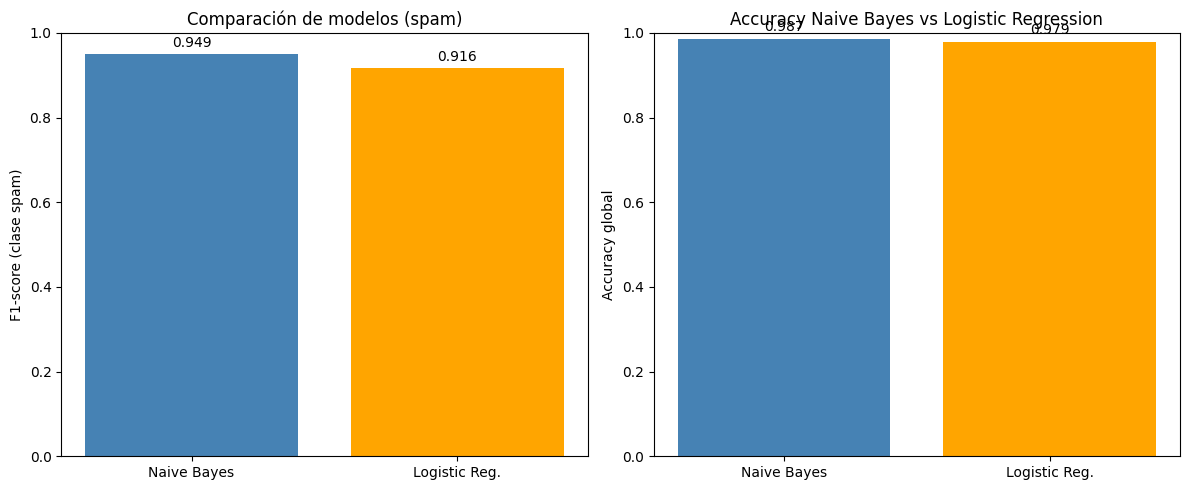

In [ ]:
# COMPARACIÓN NAIVE BAYES vs LOGISTIC REGRESSION
# Modelo de Regresión Logística para texto
log_reg = LogisticRegression(
    max_iter=1000,        # más iteraciones para asegurar convergencia
    n_jobs=-1,            # usa todos los cores disponibles
    solver="lbfgs"        # solver estándar para problemas no muy grandes
)

log_reg.fit(X_train_con, y_train)# Entrenamos la Regresión Logística con las mismas cararcteristicas y etiquetas

y_pred_log = log_reg.predict(X_test_con)# Predicciones de Logistic Regression sobre el conjunto de test

print("=== Logistic Regression (con stopwords) ===")
print("=== Matriz de confusion ===")
print(confusion_matrix(y_test, y_pred_log))# Matriz de confusión (ham/spam) para Logistic Regression
print("=== Clasificaion ===")
print(classification_report(y_test, y_pred_log))# Informe de métricas (precision, recall, f1, accuracy) para Logistic Regression

# Modelo Naive Bayes Multinomial
modelo_nb = MultinomialNB()
modelo_nb.fit(X_train_con, y_train)
# Predicciones de Naive Bayes sobre el conjunto de test
y_pred_nb = modelo_nb.predict(X_test_con)

print("=== Naive Bayes (con stopwords) ===")
print("=== Matriz de confusion ===")
print(confusion_matrix(y_test, y_pred_nb))# Matriz de confusión para Naive Bayes
print("=== Clasificaion ===")
print(classification_report(y_test, y_pred_nb))# Informe de métricas para Naive Bayes


# Extraemos datos para las graficas
# Sacamos los classification_report en formato dict para poder leer valores
report_log = classification_report(y_test, y_pred_log, output_dict=True)
report_nb  = classification_report(y_test, y_pred_nb,  output_dict=True)

# F1-score de la clase 'spam' para cada modelo
f1_spam_log = report_log["spam"]["f1-score"]
f1_spam_nb  = report_nb["spam"]["f1-score"]

# Nombres de modelos y lista de f1-scores
modelos = ["Naive Bayes", "Logistic Reg."]
f1_scores = [f1_spam_nb, f1_spam_log]

# Gráficos de comparación de modelos (F1-score de SPAM y Accuracy global)
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # 1 fila, 2 columnas

# Primer subplot: F1-score (clase spam)
bars1 = axes[0].bar(modelos, f1_scores, color=["steelblue", "orange"])
axes[0].set_ylim(0.0, 1.0)
axes[0].set_ylabel("F1-score (clase spam)")
axes[0].set_title("Comparación de modelos (spam)")

# Añadimos el valor numérico encima de cada barra
for bar, val in zip(bars1, f1_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}", #posicion horizontal centrada y mostramos tres decimañes
             ha="center", va="bottom")


# Segundo subplot: accuracy global, extraída del classification_report
acc_nb  = report_nb["accuracy"]
acc_log = report_log["accuracy"]

acc_scores = [acc_nb, acc_log]

bars2 = axes[1].bar(modelos, acc_scores, color=["steelblue", "orange"])
axes[1].set_ylim(0.0, 1.0)
axes[1].set_ylabel("Accuracy global")
axes[1].set_title("Accuracy Naive Bayes vs Logistic Regression")
# Añadimos el valor numérico encima de cada barra de accuracy
for bar, val in zip(bars2, acc_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}", #posicion horizontal centrada y mostramos tres decimañes
             ha="center", va="bottom")

plt.tight_layout() # Ajusta automáticamente los márgenes para que no se solapen
plt.show()

**SEGUNDA PARTE: EXPORTAR EL MODELO EN PRODUCTO REAL**


---



1. Serializar el modelo en binario

In [ ]:
import joblib

# 1. Guardar el modelo entrenado (Naive Bayes con stopwords)
joblib.dump(modelo_nb, "modelo_spam.pkl")

# 2. Guardar el vectorizador importante
joblib.dump(vectorizador_con, "vectorizador.pkl")

print("Modelo guardado!")

Modelo guardado!


2. CREAR EL SCRIPT DE PRODUCCIÓN

In [ ]:
import joblib
# Cargar las herramientas guardadas
modelo_cargado = joblib.load("modelo_spam.pkl")
vectorizador_cargado = joblib.load("vectorizador.pkl")

def predecir_mensaje(texto: str) -> str:
    """
    Recibe un texto y devuelve 'SPAM' o 'MENSAJE SEGURO'
    usando el modelo y vectorizador cargados.
    """
    # Transformamos el texto nuevo con el MISMO vectorizador
    texto_num = vectorizador_cargado.transform([texto])
    prediccion = modelo_cargado.predict(texto_num)
    return "SPAM" if prediccion[0] == "spam" else "MENSAJE SEGURO"

if __name__ == "__main__":
    # Probamos la IA en modo consola
    nuevo_mensaje = input("Introduce un mensaje para analizar: ")
    resultado = predecir_mensaje(nuevo_mensaje)
    print(f"Resultado: {resultado}")

Introduce un mensaje para analizar: ggg
Resultado: MENSAJE SEGURO


3. Mini API - Interfaz
- Opcion A

In [ ]:
!pip install gradio


import gradio as gr


def detectar_spam_interfaz(mensaje): # Funcion que recibe el texto y lo vectoriza
    """
    Función para la interfaz de Gradio
    """
    if not mensaje.strip():
        return "❌ Por favor, escribe un mensaje"

    # Vectorizar y predecir
    texto_vec = vectorizador_con.transform([mensaje])
    prediccion = modelo_nb.predict(texto_vec)[0] #devuelve las etiquetas de ham o spam
    probabilidades = modelo_nb.predict_proba(texto_vec)[0]

    # Preparar resultado
    if prediccion == "spam":
        resultado = f"""# 🚨 **¡SPAM DETECTADO!**

## 📊 **Probabilidades:**
- 🔴 **SPAM:** {probabilidades[1]*100:.1f}%
- 🟢 **SEGURO:** {probabilidades[0]*100:.1f}%


⚠️ **¡CUIDADO!** Este mensaje parece ser spam."""
    else:
        resultado = f"""# ✅ **MENSAJE SEGURO**

## 📊 **Probabilidades:**
- 🟢 **SEGURO:** {probabilidades[0]*100:.1f}%
- 🔴 **SPAM:** {probabilidades[1]*100:.1f}%


👍 Este mensaje parece legítimo."""

    return resultado


# Lista completa de ejemplos
ejemplos = [
    ["Hola mamá, ¿cómo estás? Te quiero mucho"],
    ["Hey, are we still meeting for coffee at 5 pm?"],
    ["I just got home, I'll call you later tonight."],
    ["¿Nos vemos esta tarde para tomar un café?"],
    ["¡FELICIDADES! Has ganado un iPhone 15 GRATIS. Reclama tu premio aquí: http://bit.ly/premio-iphone"],
    ["CONGRATULATIONS! You have won a FREE holiday. Call now to claim your prize."],
    ["URGENTE: Tu cuenta bancaria ha sido bloqueada. Haz click aquí para verificarla"]
]


# Crear interfaz
iface = gr.Interface(
    fn=detectar_spam_interfaz,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Escribe tu mensaje aquí...",
        label="📱 Mensaje a analizar"
    ),
    outputs=gr.Markdown(label="📊 Resultado"),
    title="📱 Detector Inteligente de Spam",
    description="""
    ### 🎯 Introduce un mensaje y la IA te dirá si es SPAM o es seguro
    *Modelo entrenado con Machine Learning %*

    **Idiomas soportados:** Inglés
    """,
    examples=ejemplos,
    theme="soft",
    submit_btn="🔍 ENVIAR",
    clear_btn="🗑️ LIMPIAR",
    allow_flagging="never",
    examples_per_page=7
)

iface.launch(share=True)


/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d0a1eb1f8c75ccfeb5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


https://0fce2c12dc9d70c6a3.gradio.live